In [56]:
import webrtcvad
import librosa
import numpy as np
import soundfile as sf
import os
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
%matplotlib inline

### Suppression du silence et Extraction de MFCC

In [3]:
def frame_generator(audio, sr, frame_duration_ms=30):
    """Découpe l'audio en frames de `frame_duration_ms` ms (10, 20 ou 30 ms)."""
    frame_size = int(sr * frame_duration_ms / 1000)  # Taille de la frame en échantillons
    frames = [audio[i:i + frame_size] for i in range(0, len(audio), frame_size)]
    
    # Filtrer les frames incomplètes
    return [frame for frame in frames if len(frame) == frame_size]

def float_to_pcm16(audio_float):
    """Convertit un signal float32 (-1 à 1) en PCM 16 bits (-32768 à 32767)."""
    audio_int16 = np.int16(audio_float * 32767)  # Conversion en int16
    return audio_int16.tobytes()

def vad_filter(audio, sr, frame_duration_ms=30, mode=3):
    """Supprime le silence en utilisant WebRTC VAD."""
    vad = webrtcvad.Vad(mode)  # Mode 0-3, plus élevé = plus strict
    frames = frame_generator(audio, sr, frame_duration_ms)
    
    # Vérifier que l'échantillonnage est bien supporté
    if sr not in [8000, 16000, 32000, 48000]:
        raise ValueError("WebRTC VAD supporte uniquement les fréquences 8kHz, 16kHz, 32kHz, 48kHz.")

    # Convertir chaque frame en PCM 16 bits avant le traitement
    voiced_frames = [frame for frame in frames if vad.is_speech(float_to_pcm16(frame), sr)]
    
    return np.concatenate(voiced_frames) if voiced_frames else np.array([])

In [4]:
def extract_mfcc(audio, sr, n_mfcc=13, energy_threshold=0.01):
    """Extract MFCCs, remove low-energy frames, and drop the first coefficient (energy)."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc[1:, :]  # Remove the first coefficient (energy)

    return mfcc

In [5]:
def process_audio_files(input_dir, output_dir, output_mfcc_dir):
    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".wav"):
                input_path = os.path.join(root, file)
                relative_path = os.path.relpath(input_path, input_dir)
                output_path = os.path.join(output_dir, relative_path)
                
                # Replace .wav with .mfcc for saving the MFCC file
                output_mfcc_path = os.path.join(output_mfcc_dir, relative_path.replace(".wav", ".mfcc"))
                
                # Create necessary output folders
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                os.makedirs(os.path.dirname(output_mfcc_path), exist_ok=True)
                
                # Load the audio
                y, sr = librosa.load(input_path, sr=16000)  # 16kHz for WebRTC VAD
                
                # Apply VAD to remove silence
                y_clean = vad_filter(y, sr)
                
                # Save the processed audio file (silence removed)
                sf.write(output_path, y_clean, sr)
                print(f"Processed: {output_path}")

                # Extract MFCCs from the cleaned audio (y_clean)
                mfcc_features = extract_mfcc(y_clean, sr)

                # Save the MFCC features in a human-readable .mfcc format
                np.savetxt(output_mfcc_path, mfcc_features, delimiter=",")  
                print(f"MFCC saved: {output_mfcc_path}")

In [6]:
INPUT_DIR = r"C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur"
OUTPUT_DIR = r"C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB"
OUTPUT_MFCC_DIR = r"C:\Users\abder\Documents\S8\Synthese du parole\MFCC"
process_audio_files(INPUT_DIR, OUTPUT_DIR, OUTPUT_MFCC_DIR)

Processed: C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB\F1\Test\10s\Seg1.wav
MFCC saved: C:\Users\abder\Documents\S8\Synthese du parole\MFCC\F1\Test\10s\Seg1.mfcc
Processed: C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB\F1\Test\10s\Seg2.wav
MFCC saved: C:\Users\abder\Documents\S8\Synthese du parole\MFCC\F1\Test\10s\Seg2.mfcc
Processed: C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB\F1\Test\10s\Seg3.wav
MFCC saved: C:\Users\abder\Documents\S8\Synthese du parole\MFCC\F1\Test\10s\Seg3.mfcc
Processed: C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB\F1\Test\10s\Seg4.wav
MFCC saved: C:\Users\abder\Documents\S8\Synthese du parole\MFCC\F1\Test\10s\Seg4.mfcc
Processed: C:\Users\abder\Documents\S8\Synthese du parole\Reconnaissance_du_locuteur_SB\F1\Test\10s\Seg5.wav
MFCC saved: C:\Users\abder\Documents\S8\Synthese du parole\MFCC\F1\Test\10s\Seg5.mfcc
Processed: C:\Users\abder

### Création des modèles GMM

In [20]:
def load_mfcc_for_speaker(train_mfcc_path):
    """Load the MFCC file for a speaker from the 'Train' folder."""
    for file in os.listdir(train_mfcc_path):
        if file.endswith(".mfcc"):  # Ensure correct format
            file_path = os.path.join(train_mfcc_path, file)
            return np.loadtxt(file_path, delimiter=",").T  # Load & transpose MFCC

    return None  # Return None if no valid MFCC file is found

def train_gmm_for_speakers(mfcc_dir,output_dir, n_components_list=[8, 16, 32, 64, 128, 256]):
    """Train GMM models for each speaker using only the 'Train' folder MFCC."""
    
    speakers = os.listdir(mfcc_dir)  # Each folder is a speaker

    for speaker in speakers:
        train_path = os.path.join(mfcc_dir, speaker, "Train")  # Only use Train folder
        model_dir = os.path.join(output_dir, speaker)  # Save models in MFCC/{speaker}/Model/
        os.makedirs(model_dir, exist_ok=True)  # Create model directory if needed
        
        mfcc_features = load_mfcc_for_speaker(train_path)
        
        if mfcc_features is None:
            print(f"Skipping {speaker}, no MFCC data found in Train folder.")
            continue
        
        for n_components in n_components_list:
            gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
            gmm.fit(mfcc_features)  # Train the model
            
            model_filename = os.path.join(model_dir, f"{speaker}_{n_components}.gmm")
            joblib.dump(gmm, model_filename)  # Save model
            print(f"Saved GMM model for {speaker} with {n_components} components at {model_filename}") 

In [7]:
mfcc_dir = r"C:\Users\abder\Documents\S8\Synthese du parole\MFCC"
output_dir = r"C:\Users\abder\Documents\S8\Synthese du parole\GMM"
train_gmm_for_speakers(mfcc_dir,output_dir)

NameError: name 'train_gmm_for_speakers' is not defined

In [11]:
mfcc_dir = r"C:\Users\abder\Documents\S8\Synthese du parole\MFCC"
output_dir = r"C:\Users\abder\Documents\S8\Synthese du parole\GMM"

In [13]:
def load_gmm_models(gmm_dir, n_g,gender):
    models = {}
    for speaker in os.listdir(gmm_dir):
        speaker_dir = os.path.join(gmm_dir, speaker)
        if os.path.isdir(speaker_dir):  
            if speaker[0] == gender :
                model_path = os.path.join(speaker_dir, f"{speaker}_{n_g}.gmm")  
                
                if os.path.exists(model_path):
                    models[speaker] = joblib.load(model_path)
                    #print(f"Loaded GMM model for {speaker} with {n_g} components.")
                else:
                    print(f"Model file for {speaker} with {n_g} components not found.")        
    return models
load_gmm_models(output_dir,8,"H")

{'H1': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H10': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H2': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H3': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H4': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H5': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H6': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H7': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H8': GaussianMixture(covariance_type='diag', n_components=8, random_state=42),
 'H9': GaussianMixture(covariance_type='diag', n_components=8, random_state=42)}

In [15]:
def test_mfcc(mfcc_data, models):
    speaker_likelihoods = {}
    
    for speaker, model in models.items():
        log_likelihood = model.score(mfcc_data.T)  
        speaker_likelihoods[speaker] = log_likelihood
        
    # Find the speaker with the highest log-likelihood
    predicted_speaker = max(speaker_likelihoods, key=speaker_likelihoods.get)
    
    return predicted_speaker, speaker_likelihoods

### Identification du Locuteur

In [107]:
def Evaluation(Gmm_dir, mfcc_dir, segs=["5s", "10s", "15s"], n_component=[8, 16, 32, 64, 128, 256]):
    speakers = os.listdir(mfcc_dir)
    tbi_results = {comp: {seg: 0 for seg in segs} for comp in n_component}
    
    for gmm in n_component:
        print("Number of Components:", gmm)
        
        for seg in segs:
            print("Segment:", seg)
            tb = 0
            nbr_tests = 0
            
            for speaker in speakers:
                print("Speaker:", speaker)
                
                models = load_gmm_models(Gmm_dir, gmm, speaker[0])
                test_path = os.path.join(mfcc_dir, speaker, "Test", seg)
                
                for mfcc in os.listdir(test_path):
                    test = os.path.join(test_path, mfcc)
                    mfcc_data = np.loadtxt(test, delimiter=",")
                    
                    predicted_speaker, probs = test_mfcc(mfcc_data, models)
                    print(f"Predicted speaker: {predicted_speaker} - Original speaker: {speaker}")
                    
                    nbr_tests += 1
                    if predicted_speaker == speaker:
                        tb += 1
            
            accuracy = tb / nbr_tests if nbr_tests > 0 else 0
            tbi_results[gmm][seg] = accuracy
            print(f"Accuracy = {accuracy}")
            print("*" * 150)
        
        print("-" * 150)
    
    print("=" * 150)

    for gmm in n_component:
        y = [tbi_results[gmm][seg] for seg in segs]
        plt.figure()
        plt.plot(segs, y, marker='o')
        plt.xlabel('Segment Duration (s)')
        plt.ylabel('Accuracy (TBI)')
        plt.title(f'Accuracy for {gmm} GMM Components')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    all_accuracies = [tbi_results[gmm][seg] for gmm in n_component for seg in segs]
    ymin = min(all_accuracies)-0.5
    ymax = max(all_accuracies)+0.5
    
    for seg in segs:
        x = n_component
        y = [tbi_results[gmm][seg] for gmm in n_component]
        plt.figure()
        plt.plot(x, y, marker='o')
        plt.xticks(n_component)
        plt.ylim(ymin, ymax)  # Set fixed y-axis range
        plt.xlabel('Number of GMM Components')
        plt.ylabel('Accuracy (TBI)')
        plt.title(f'Accuracy for Segment {seg}')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Number of Components: 8
Segment: 5s
Speaker: F1
Predicted speaker: F12 - Original speaker: F1
Predicted speaker: F11 - Original speaker: F1
Predicted speaker: F5 - Original speaker: F1
Predicted speaker: F2 - Original speaker: F1
Predicted speaker: F5 - Original speaker: F1
Speaker: F10
Predicted speaker: F10 - Original speaker: F10
Predicted speaker: F10 - Original speaker: F10
Predicted speaker: F10 - Original speaker: F10
Predicted speaker: F10 - Original speaker: F10
Predicted speaker: F10 - Original speaker: F10
Speaker: F11
Predicted speaker: F11 - Original speaker: F11
Predicted speaker: F11 - Original speaker: F11
Predicted speaker: F11 - Original speaker: F11
Predicted speaker: F11 - Original speaker: F11
Predicted speaker: F11 - Original speaker: F11
Speaker: F12
Predicted speaker: F12 - Original speaker: F12
Predicted speaker: F12 - Original speaker: F12
Predicted speaker: F12 - Original speaker: F12
Predicted speaker: F11 - Original speaker: F12
Predicted speaker: F12 - Ori

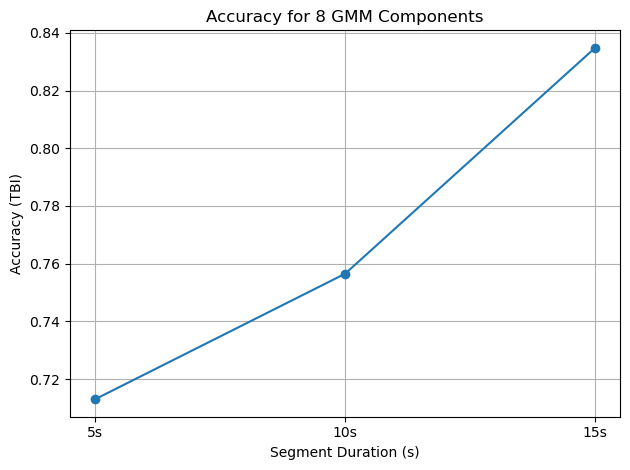

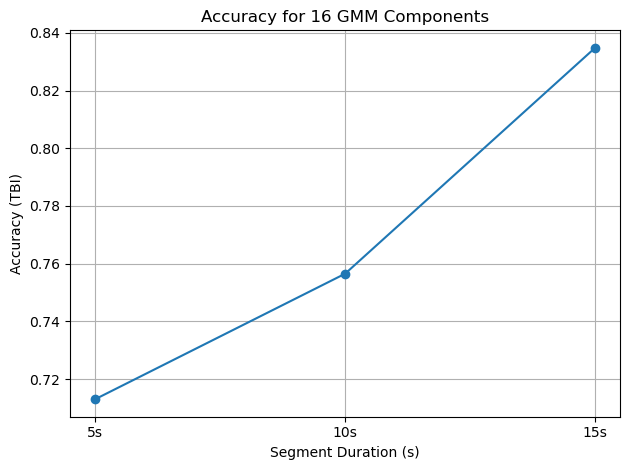

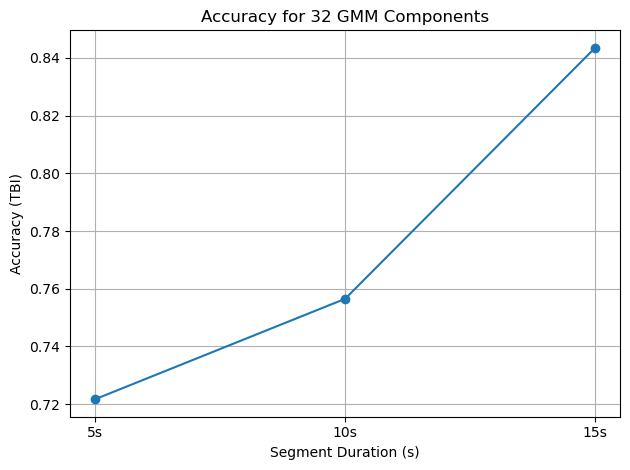

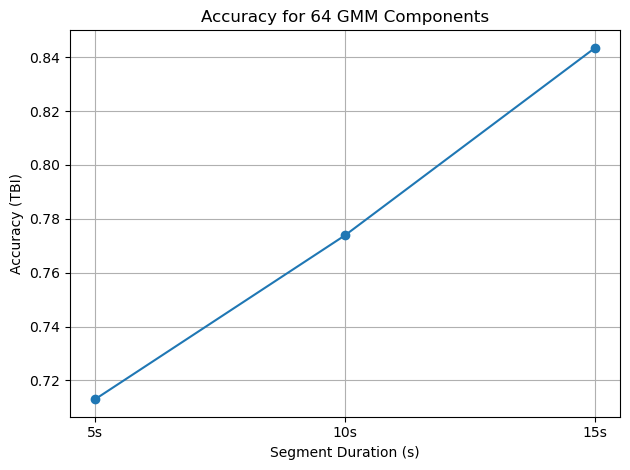

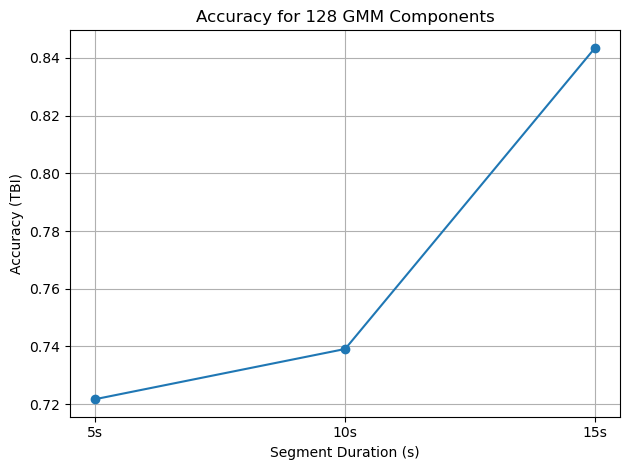

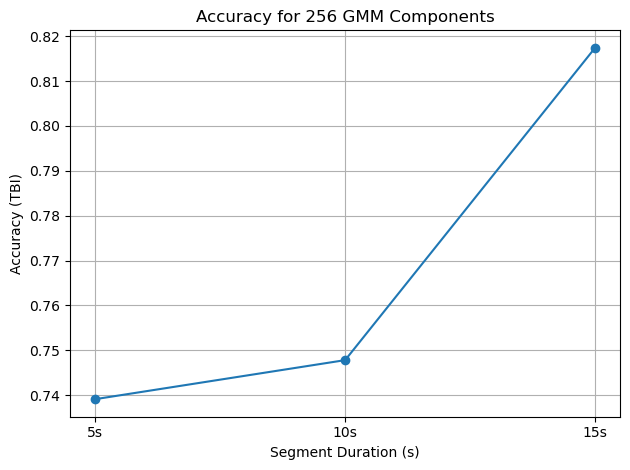

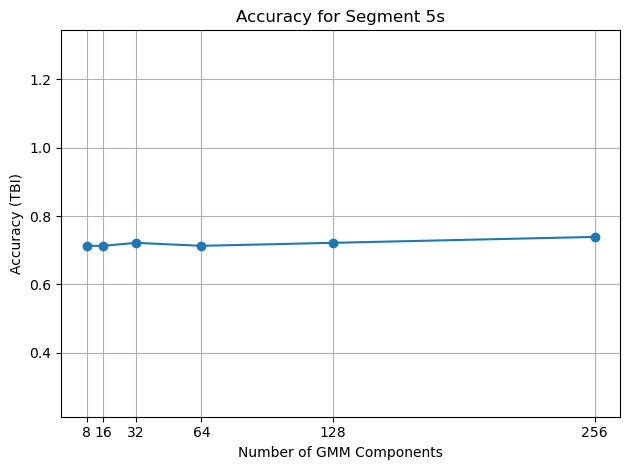

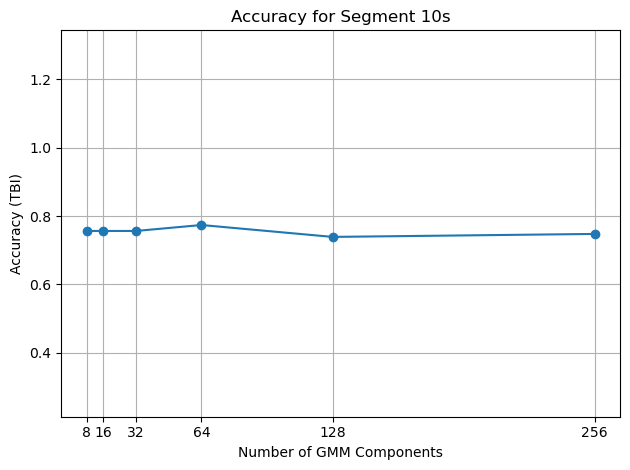

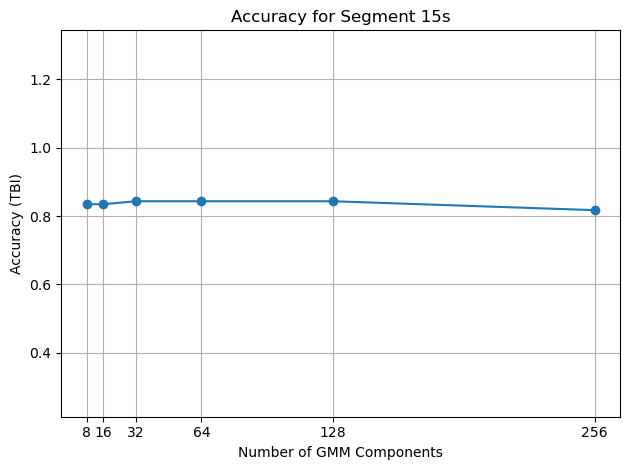

In [109]:
Evaluation(output_dir,mfcc_dir)

### Vérification du Locuteur

In [20]:
def Verification(Gmm_dir, mfcc_dir, segs=["5s", "10s", "15s"], n_component=[8, 16, 32, 64, 128, 256]):
    results = []
    speakers = os.listdir(mfcc_dir)
    
    for gmm in n_component:
        for seg in segs:
            for speaker in speakers:                
                models = load_gmm_models(Gmm_dir, gmm, speaker[0])  
                test_path = os.path.join(mfcc_dir, speaker, "Test", seg)
                
                for mfcc in os.listdir(test_path):
                    test = os.path.join(test_path, mfcc)
                    mfcc_data = np.loadtxt(test, delimiter=",")
                    
                    for speaker_p, model in models.items():
                        log_likelihood = model.score(mfcc_data.T)
                        results.append({
                            'n_comp': gmm,
                            'seg': seg,
                            'real_speaker': speaker,
                            'predicted_speaker': speaker_p,
                            'score': log_likelihood
                        })
    
    data = pd.DataFrame(results)
    return data

In [21]:
scores = Verification(output_dir,mfcc_dir)

In [40]:
minv = float(scores['score'].min())
maxv = float(scores['score'].max())
segs = sorted(scores['seg'].unique())
comps = sorted(scores['n_comp'].unique())
thresholds = np.linspace(minv, maxv, 180)

eer_results = {}

for comp in comps:
    for seg in segs:
        filtered = scores[(scores['n_comp'] == comp) & (scores['seg'] == seg)].copy()

        if filtered.empty:
            print(f"[SKIP] No data for comp={comp}, seg={seg}")
            continue

        real = filtered['real_speaker'].values
        pred = filtered['predicted_speaker'].values
        score = filtered['score'].values

        is_genuine = real == pred
        is_impostor = real != pred

        total_genuine = np.sum(is_genuine)
        total_impostor = np.sum(is_impostor)

        if total_genuine == 0 or total_impostor == 0:
            print(f"[SKIP] Not enough data to compute EER for comp={comp}, seg={seg}")
            continue

        FAR_list = []
        FRR_list = []

        for thresh in thresholds:
            FR = np.sum((is_genuine) & (score < thresh))
            FA = np.sum((is_impostor) & (score >= thresh))

            FRR = FR / total_genuine
            FAR = FA / total_impostor

            FRR_list.append(FRR)
            FAR_list.append(FAR)

        FRR_array = np.array(FRR_list)
        FAR_array = np.array(FAR_list)
        abs_diff = np.abs(FRR_array - FAR_array)

        eer_index = np.argmin(abs_diff)
        eer_threshold = thresholds[eer_index]
        eer_value = (FAR_array[eer_index] + FRR_array[eer_index]) / 2

        print(f"[EER] comp={comp}, seg={seg} → EER={eer_value:.4f} at threshold={eer_threshold:.2f}")

        eer_results.setdefault(comp, {})[seg] = {
            'eer_threshold': eer_threshold,
            'eer_value': eer_value
        }

        # Plotting
        plt.figure(figsize=(10, 6))
        plt.plot(thresholds, FAR_array, label='FAR', color='blue')
        plt.plot(thresholds, FRR_array, label='FRR', color='red')
        plt.axvline(eer_threshold, color='green', linestyle='--', label=f'EER Threshold = {eer_threshold:.2f}')
        plt.scatter(eer_threshold, eer_value, color='black', label=f'EER = {eer_value:.2%}', zorder=5)

        plt.xlabel('Threshold')
        plt.ylabel('Rate')
        plt.title(f'DET Curve - comp={comp}, seg={seg}')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        filename = f'eer_plot_comp{comp}_seg{seg}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"[PLOT SAVED] {filename}")


[EER] comp=8, seg=10s → EER=0.3127 at threshold=-53.10
[PLOT SAVED] eer_plot_comp8_seg10s.png
[EER] comp=8, seg=15s → EER=0.2246 at threshold=-52.07
[PLOT SAVED] eer_plot_comp8_seg15s.png
[EER] comp=8, seg=5s → EER=0.2608 at threshold=-52.58
[PLOT SAVED] eer_plot_comp8_seg5s.png
[EER] comp=16, seg=10s → EER=0.3109 at threshold=-53.10
[PLOT SAVED] eer_plot_comp16_seg10s.png
[EER] comp=16, seg=15s → EER=0.2118 at threshold=-52.58
[PLOT SAVED] eer_plot_comp16_seg15s.png
[EER] comp=16, seg=5s → EER=0.2418 at threshold=-52.58
[PLOT SAVED] eer_plot_comp16_seg5s.png
[EER] comp=32, seg=10s → EER=0.3066 at threshold=-53.61
[PLOT SAVED] eer_plot_comp32_seg10s.png
[EER] comp=32, seg=15s → EER=0.2063 at threshold=-52.58
[PLOT SAVED] eer_plot_comp32_seg15s.png
[EER] comp=32, seg=5s → EER=0.2380 at threshold=-53.10
[PLOT SAVED] eer_plot_comp32_seg5s.png
[EER] comp=64, seg=10s → EER=0.3001 at threshold=-54.12
[PLOT SAVED] eer_plot_comp64_seg10s.png
[EER] comp=64, seg=15s → EER=0.2042 at threshold=-53

In [42]:
print("EER Results for each component and segment:")
print(eer_results)

EER Results for each component and segment:
{8: {'10s': {'eer_threshold': -53.096272485498716, 'eer_value': 0.3127430187345352}, '15s': {'eer_threshold': -52.06999227578984, 'eer_value': 0.22458465889006718}, '5s': {'eer_threshold': -52.58313238064427, 'eer_value': 0.26079886885825376}}, 16: {'10s': {'eer_threshold': -53.096272485498716, 'eer_value': 0.3108695652173913}, '15s': {'eer_threshold': -52.58313238064427, 'eer_value': 0.21178861788617886}, '5s': {'eer_threshold': -52.58313238064427, 'eer_value': 0.24181689642983387}}, 32: {'10s': {'eer_threshold': -53.609412590353145, 'eer_value': 0.30664545775892543}, '15s': {'eer_threshold': -52.58313238064427, 'eer_value': 0.20625662778366916}, '5s': {'eer_threshold': -53.096272485498716, 'eer_value': 0.23799929303640863}}, 64: {'10s': {'eer_threshold': -54.12255269520759, 'eer_value': 0.300141392718275}, '15s': {'eer_threshold': -53.096272485498716, 'eer_value': 0.2042241074584659}, '5s': {'eer_threshold': -53.609412590353145, 'eer_value'

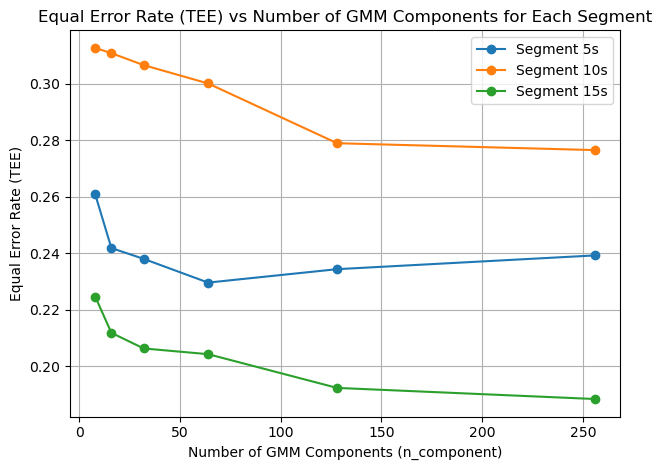

In [60]:
components = sorted(eer_results.keys())  # GMM components
segments = ['5s', '10s', '15s']  # Segments

# Plot each segment on the same figure
for seg in segments:
    y = [eer_results[nc][seg]['eer_value'] for nc in components]  # Get TEE for each component
    plt.plot(components, y, marker='o', label=f'Segment {seg}')  # Plot segment

# Adding labels and title
plt.xlabel('Number of GMM Components (n_component)')
plt.ylabel('Equal Error Rate (TEE)')
plt.title('Equal Error Rate (TEE) vs Number of GMM Components for Each Segment')
plt.grid(True)
plt.legend()

# Display the plot
plt.tight_layout()
plt.show()